In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

year_groups = ["Group1", "Group2", "Group3", "Group4", "Group5"]
audit_results = []
combined_df = pd.DataFrame()

for group in year_groups:
    # 讀取原始的平衡資料以獲取具備醫學意義的真實數值
    file_path = f'./balance_data_{group}.csv'
    if not os.path.exists(file_path):
        print(f"找不到檔案: {file_path}")
        continue
        
    df = pd.read_csv(file_path)
    
    # 確保標籤格式一致 (排除 9.0，並轉換 3.0->1.0, 2.0->0.0)
    df = df[df['DIQ010'] != 9.0].reset_index(drop=True)
    df['DIQ010'] = df['DIQ010'].replace({3.0: 1.0, 2.0: 0.0})
    
    # 計算樣本數與類別分佈
    total_samples = len(df)
    health_count = len(df[df['DIQ010'] == 0.0])
    risk_count = len(df[df['DIQ010'] == 1.0])
    
    # 紀錄關鍵特徵的平均值
    audit_results.append({
        '分區 (Client)': group,
        '總樣本數': total_samples,
        '健康 (0.0)': health_count,
        '風險 (1.0)': risk_count,
        '平均年齡': round(df['RIDAGEYR'].mean(), 2),
        '平均糖化血色素 (LBXGH)': round(df['LBXGH'].mean(), 2),
        '平均空腹血糖 (LBXGLU)': round(df['LBXGLU'].mean(), 2),
        '平均壞膽固醇 (LBDLDL)': round(df['LBDLDL'].mean(), 2)
    })
    
    # 標記分區名稱並合併，供後續繪圖使用
    df['Client_Group'] = group
    combined_df = pd.concat([combined_df, df], axis=0)

# 將統計結果轉為資料表並顯示
audit_table = pd.DataFrame(audit_results)
display(audit_table)

,分區 (Client),總樣本數,健康 (0.0),風險 (1.0),平均年齡,平均糖化血色素 (LBXGH),平均空腹血糖 (LBXGLU),平均壞膽固醇 (LBDLDL)
0,Group1,972,486,486,47.79,6.24,125.00,106.99
1,Group2,716,358,358,50.68,6.28,121.82,107.26
2,Group3,1392,696,696,50.33,6.34,123.73,105.96
3,Group4,1732,866,866,51.71,6.41,128.69,105.02
4,Group5,2474,1237,1237,52.77,6.32,125.53,101.26


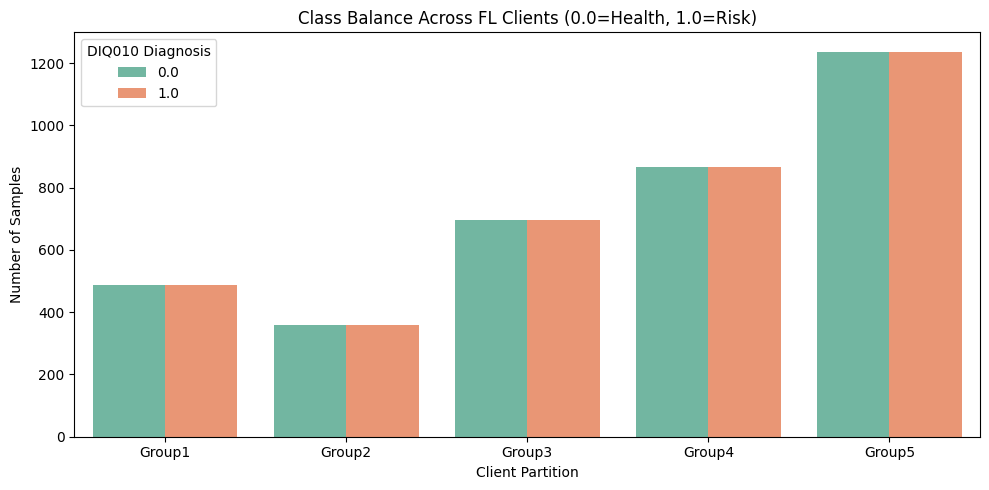

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(data=combined_df, x='Client_Group', hue='DIQ010', palette='Set2')
plt.title('Class Balance Across FL Clients (0.0=Health, 1.0=Risk)')
plt.ylabel('Number of Samples')
plt.xlabel('Client Partition')
plt.legend(title='DIQ010 Diagnosis')
plt.tight_layout()

if not os.path.exists("./output"):
    os.makedirs("./output")
plt.savefig("./output/client_class_balance.png")
plt.show()

C:\Users\Yang\AppData\Local\Temp\ipykernel_17832\7503020.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Client_Group', y='RIDAGEYR', ax=axes[0], palette='Pastel1')
C:\Users\Yang\AppData\Local\Temp\ipykernel_17832\7503020.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Client_Group', y='LBXGLU', ax=axes[1], palette='Pastel1')


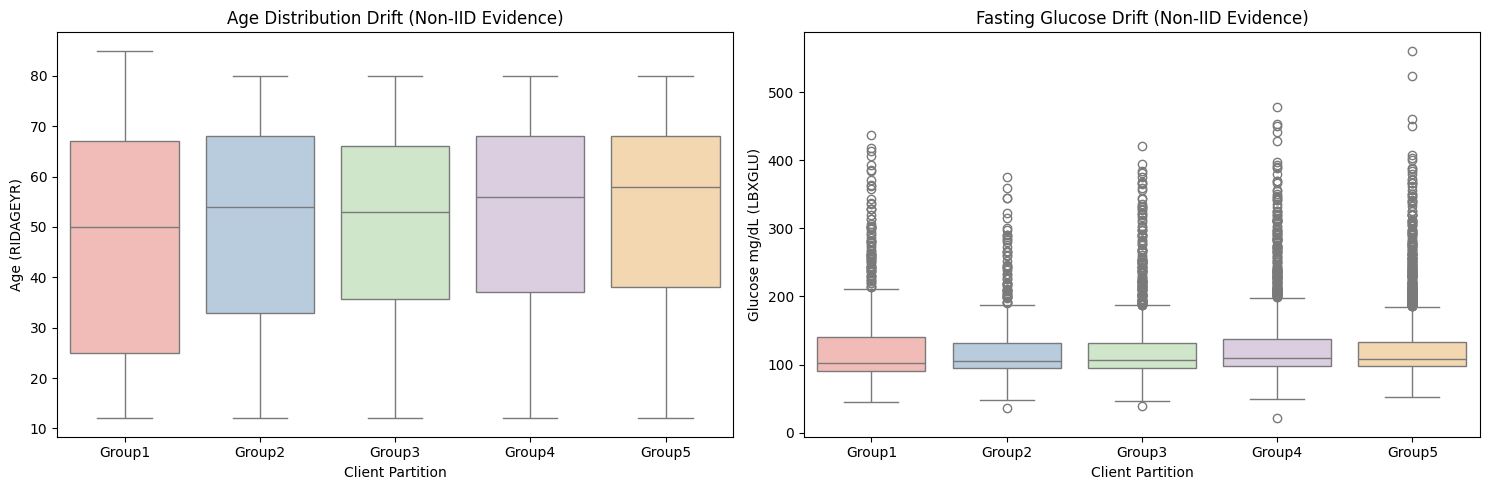

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 繪製年齡分佈差異
sns.boxplot(data=combined_df, x='Client_Group', y='RIDAGEYR', ax=axes[0], palette='Pastel1')
axes[0].set_title('Age Distribution Drift (Non-IID Evidence)')
axes[0].set_ylabel('Age (RIDAGEYR)')
axes[0].set_xlabel('Client Partition')

# 繪製空腹血糖分佈差異
sns.boxplot(data=combined_df, x='Client_Group', y='LBXGLU', ax=axes[1], palette='Pastel1')
axes[1].set_title('Fasting Glucose Drift (Non-IID Evidence)')
axes[1].set_ylabel('Glucose mg/dL (LBXGLU)')
axes[1].set_xlabel('Client Partition')

plt.tight_layout()
plt.savefig("./output/non_iid_distribution.png")
plt.show()